##CHURN MACHINE LEARNING

In [ ]:
#Import thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

In [ ]:
#Dọc dữ liệu
url= "https://drive.google.com/file/d/1Vmvsp_mxgDp1Wi1G64LQ9P9rCpFG70E8/view"
file_id = url.split('/')[-2]
gdrive_url = "https://drive.google.com/uc?id=" + file_id
df = pd.read_csv(gdrive_url)
df.head(3)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [ ]:
#Kiểm tra một số thông tin tổng quan
print("Thông tin chung:")
df.info()
print("-"*50)
print("Kích thước tập dữ liệu:")
print(df.shape)
print("-"*50)
print("Định dạng các cột:")
df.dtypes



Thông tin chung:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
--------------------------------------------------
Kích thước tập dữ liệu:
(10000, 12)
--------------------------------------------------
Định dạng các c

,0
customer_id,int64
credit_score,int64
country,object
gender,object
age,int64
tenure,int64
balance,float64
products_number,int64
credit_card,int64
active_member,int64


##I/ Data Dictionary

##Chi tiết các cột:
- customer_id: Account Number
- credit_score: Credit Score
- country: Country of Residence
- gender: Sex
- age: Age
- tenure: From how many years he/she is having bank acc in ABC Bank
- balance: Account Balance
- product_number: Number of Procduct from bank
- credit_card: Does this customer have a credit card
- active_member: Is he/she  an active  Member of the bank?
- estimated_salary: Salary of Account holder
- churn: Churn Status

#II/ Thông tin tổng quan

In [ ]:
#In 5 dòng đầu dữ liệu
df.head()


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
#Xem thông số diễn tả
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
#Xem tương quan
df.corr(numeric_only=True)

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
customer_id,1.000000,0.005308,0.009497,-0.014883,-0.012419,0.016972,-0.014025,0.001665,0.015271,-0.006248
credit_score,0.005308,1.000000,-0.003965,0.000842,0.006268,0.012238,-0.005458,0.025651,-0.001384,-0.027094
age,0.009497,-0.003965,1.000000,-0.009997,0.028308,-0.030680,-0.011721,0.085472,-0.007201,0.285323
tenure,-0.014883,0.000842,-0.009997,1.000000,-0.012254,0.013444,0.022583,-0.028362,0.007784,-0.014001
balance,-0.012419,0.006268,0.028308,-0.012254,1.000000,-0.304180,-0.014858,-0.010084,0.012797,0.118533
products_number,0.016972,0.012238,-0.030680,0.013444,-0.304180,1.000000,0.003183,0.009612,0.014204,-0.047820
credit_card,-0.014025,-0.005458,-0.011721,0.022583,-0.014858,0.003183,1.000000,-0.011866,-0.009933,-0.007138
active_member,0.001665,0.025651,0.085472,-0.028362,-0.010084,0.009612,-0.011866,1.000000,-0.011421,-0.156128
estimated_salary,0.015271,-0.001384,-0.007201,0.007784,0.012797,0.014204,-0.009933,-0.011421,1.000000,0.012097
churn,-0.006248,-0.027094,0.285323,-0.014001,0.118533,-0.047820,-0.007138,-0.156128,0.012097,1.000000


<Axes: >

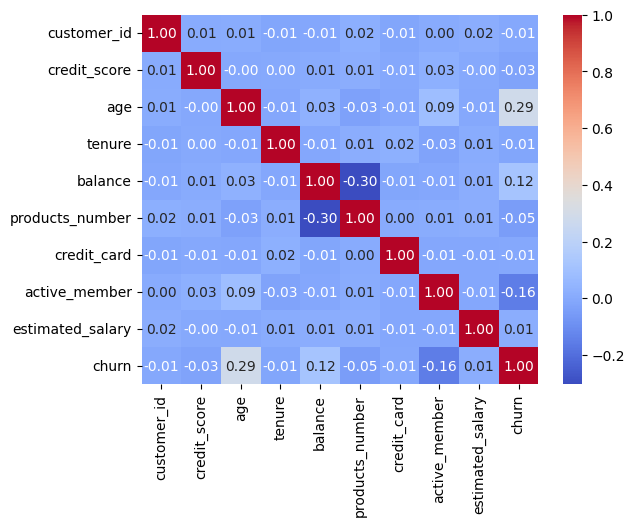

In [ ]:
#biểu dồ heatmap tương quan
sns.heatmap(df.corr(numeric_only=True),  fmt=".2f",annot=True,cmap="coolwarm")

##Một số thông tin:
- Tuổi(Age) càng cao thì có xu hướng Churn nhiều (tương quan +0.29)
- Active Member: Người dùng là "active Member" thì khả năng churn ít hơn (-0.16)
- Balance: Người có balance cao dễ churn hơn (0.12). Có thể do người dùng có nhiều sự lựa chọn ở các ngân hàng khác nhau
- Các yếu tố còn lại không có ảnh hưởng tuyến tính đến khả năng Churn


#III/Kiểm tra và tiền xử lý dữ liệu

In [ ]:
#Kiểm tra giá trị null
df.isnull().sum()

,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [ ]:
#Kiểm tra giá trị trùng lặp
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


###Tạo dữ liệu df_model để dùng cho việc train mô hình

In [ ]:
#1) Drop các cột không cần đưa vào mô hình, tạo df_model
drop_column=["customer_id"]


In [ ]:
df_model=df.drop(columns=drop_column,errors="ignore")

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   credit_score      10000 non-null  int64  
 1   country           10000 non-null  object 
 2   gender            10000 non-null  object 
 3   age               10000 non-null  int64  
 4   tenure            10000 non-null  int64  
 5   balance           10000 non-null  float64
 6   products_number   10000 non-null  int64  
 7   credit_card       10000 non-null  int64  
 8   active_member     10000 non-null  int64  
 9   estimated_salary  10000 non-null  float64
 10  churn             10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


#IV/ Khảo sát dữ liệu

##1) Khảo sát nhãn dữ liệu

Số lượng hành khách Churn: 2037
Số lượng hành khách không Churn: 7963


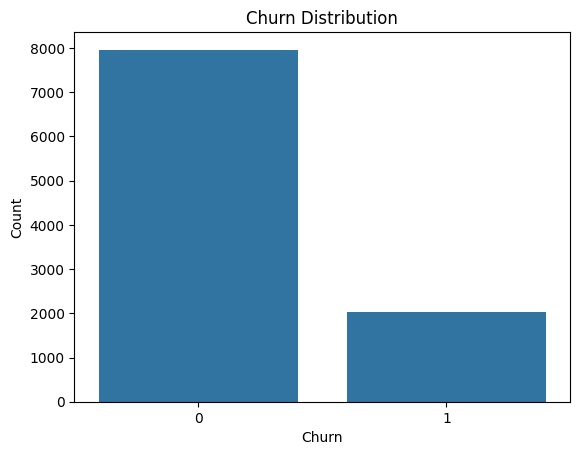

In [ ]:
#Vẽ biểu đồ thể hiện số lượng CHURN
print("Số lượng hành khách Churn:",len(df_model["churn"][df_model["churn"]==1]))
print("Số lượng hành khách không Churn:",len(df_model["churn"][df_model["churn"]==0]))

sns.countplot(x="churn",data=df_model)
plt.xlabel("Churn")
plt.ylabel("Count")
plt.title("Churn Distribution")
plt.show()

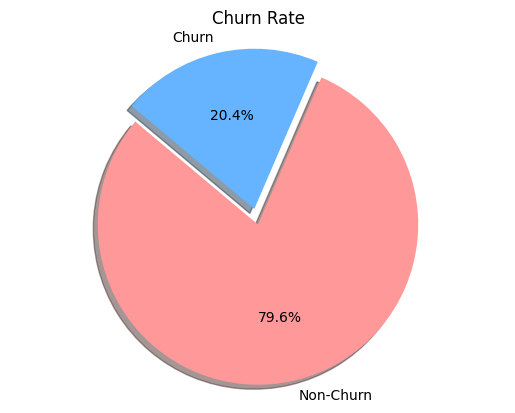

In [ ]:
#Vẽ biểu đồ tròn thể hiện tỷ lệ churn và churn
labels = ['Non-Churn', 'Churn']
sizes = [len(df_model['churn'][df_model['churn']==0]), len(df_model['churn'][df_model['churn']==1])]
colors = ['#ff9999','#66b3ff']
explode = (0.1, 0)
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.axis('equal')
plt.title('Churn Rate')
plt.show()

In [ ]:
#Tỷ lệ Churn
print('Tỷ lệ Churn:',len(df_model['churn'][df_model['churn']==1])/len(df_model))

Tỷ lệ Churn: 0.2037


#Nhận xét:
Tỷ lệ Churn chiếm 20.4%, dữ liệu mất cân bằng nhẹ

In [ ]:
#In giá trị unique của mỗi cột
df_model.nunique()

,0
credit_score,460
country,3
gender,2
age,70
tenure,11
balance,6382
products_number,4
credit_card,2
active_member,2
estimated_salary,9999


In [ ]:
#Xem định dạng các cột
df_model.dtypes

,0
credit_score,int64
country,object
gender,object
age,int64
tenure,int64
balance,float64
products_number,int64
credit_card,int64
active_member,int64
estimated_salary,float64


In [ ]:
#tìm các feature

target = "churn"
X = df_model.drop(columns=[target])

num_cols = []
cat2_cols = []
cat_cols = []

for col in X.columns:
    nunq = X[col].nunique(dropna=True)
    dtype = X[col].dtype

    if dtype == "object":
        cat_cols.append(col)
    else:
        # numeric
        if nunq <= 2:
            cat2_cols.append(col)
        elif nunq <= 10:
            cat_cols.append(col)
        else:
            num_cols.append(col)

print("num_cols:", num_cols)
print("cat2_cols:", cat2_cols)
print("cat_cols:", cat_cols)


num_cols: ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']
cat2_cols: ['credit_card', 'active_member']
cat_cols: ['country', 'gender', 'products_number']


##Visualize các cột feature

##Biểu đồ cột thể hiện tỷ lệ Churn của các cột Cat

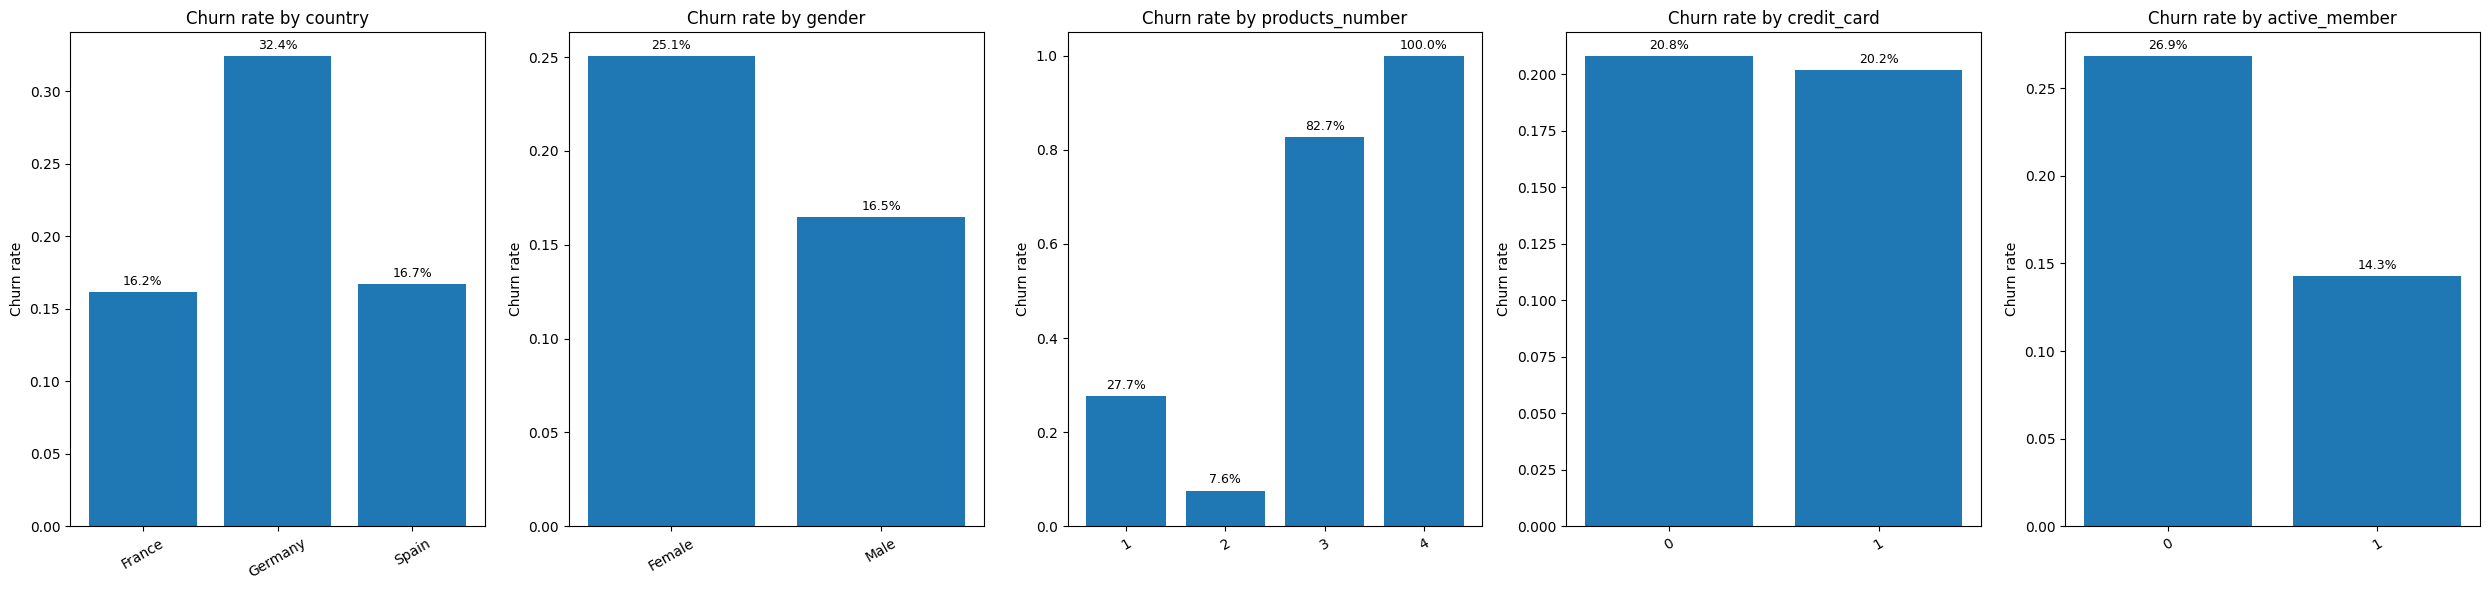

In [ ]:
# Visualization các cột features dạng categories:

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
axes = axes.ravel()

for i, col in enumerate(cat_cols + cat2_cols):
    rate = (
        df_model.groupby(col)[target]
        .mean())


    bars = axes[i].bar(rate.index.astype(str), rate.values)
    axes[i].set_title(f"Churn rate by {col}")
    axes[i].set_ylabel("Churn rate")
    axes[i].tick_params(axis="x", rotation=30)

    axes[i].bar_label(bars, labels=[f"{v*100:.1f}%" for v in rate.values], padding=3, fontsize=9)


plt.tight_layout()
plt.show()

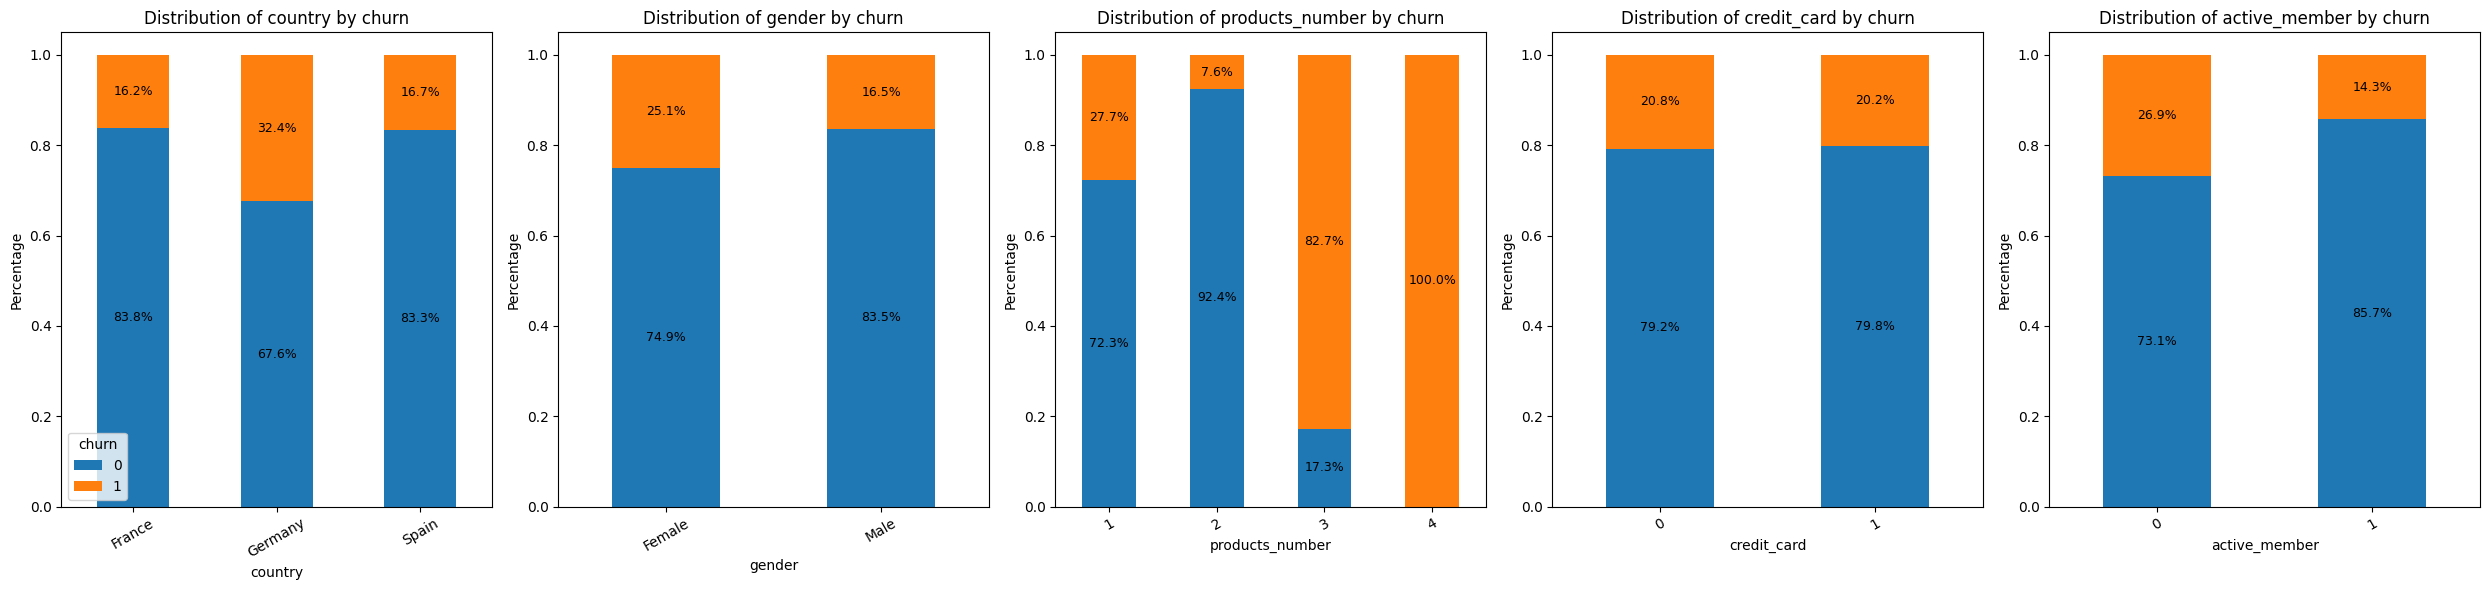

In [ ]:
#Biểu đồ cột chồng
fig, axes = plt.subplots(1, 5, figsize=(25, 6))
axes = axes.ravel()
for i,col in enumerate(cat_cols + cat2_cols):
  tmp = df_model.groupby(col)["churn"].value_counts(normalize=True).unstack()
  tmp.plot(kind="bar", stacked=True, ax=axes[i], legend=(i==0))
  ax = axes[i]

  for container in ax.containers:
        ax.bar_label(
            container,
            labels=[f"{v*100:.1f}%" if v > 0 else "" for v in container.datavalues],
            label_type="center",
            fontsize=9)

  axes[i].set_title(f"Distribution of {col} by churn")
  axes[i].set_xlabel(col)
  axes[i].set_ylabel("Percentage")
  axes[i].tick_params(axis="x", rotation=30)


plt.tight_layout()
plt.show()

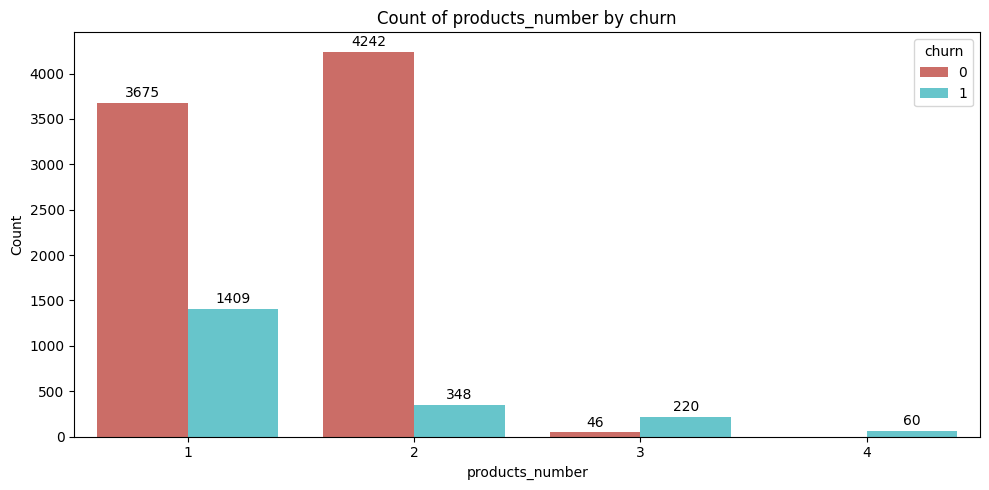

In [ ]:
#Biểu đồ count theo products_number
fig, ax = plt.subplots(figsize=(10,5))
sns.countplot(data=df_model, x="products_number", hue="churn", palette="hls", ax=ax)
ax.set_title("Count of products_number by churn")
ax.set_xlabel("products_number")
ax.set_ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

plt.tight_layout()
plt.show()

#Nhận xét:

1) Country

Germany churn cao nhất ~32.4%

France ~16.2%, Spain ~16.7% (thấp hơn nhiều)

=> Country là biến tác động khá mạnh đến churn, đặc biệt nhóm khách ở Germany rủi ro rời đi cao hơn.

2) Gender

Female churn ~25.1% cao hơn Male ~16.5%

=> Có chênh lệch theo giới tính, khách hàng nhóm Nữ có tỷ lệ churn cao hơn, có thể do chính sách, sản phẩm của công ty chưa đáp ứng được mong muốn của phái Nữ

3) products_number

2 sản phẩm: churn thấp nhất ~7.6%

1 sản phẩm: churn ~27.7%

3 sản phẩm: churn cực cao ~82.7%

4 sản phẩm: 100% churn

=>Nhóm 3,4 sản phẩm có số khách hàng ít nên dù tỷ lệ churn là 100% cũng không nói lên chắc chắn là nhóm products_number=3 hoặc sẽ churn nhiều hoặc churn hoàn toàn

Nhóm 1 sản phẩm là nhóm cần chú ý, khách có 2 sản phẩm churn thấp rõ rệt so với 1 sản phẩm.

4) credit_card

Churn và không gần như giống nhau (~20.8% vs ~20.2%)

=> Biến này không phân tách churn rõ (ít giá trị dự báo).

5) active_member

Không active: churn ~26.9%

Active: churn ~14.3%

=> khách active rời đi ít hơn nhiều.

In [ ]:
num_cols

['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']

/tmp/ipython-input-3577776856.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tmp.groupby("bin")[target].agg(["mean","size"])
/tmp/ipython-input-3577776856.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tmp.groupby("bin")[target].agg(["mean","size"])
/tmp/ipython-input-3577776856.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = tmp.groupby("bin")[target].agg(["mean","size"])
/tmp/ip

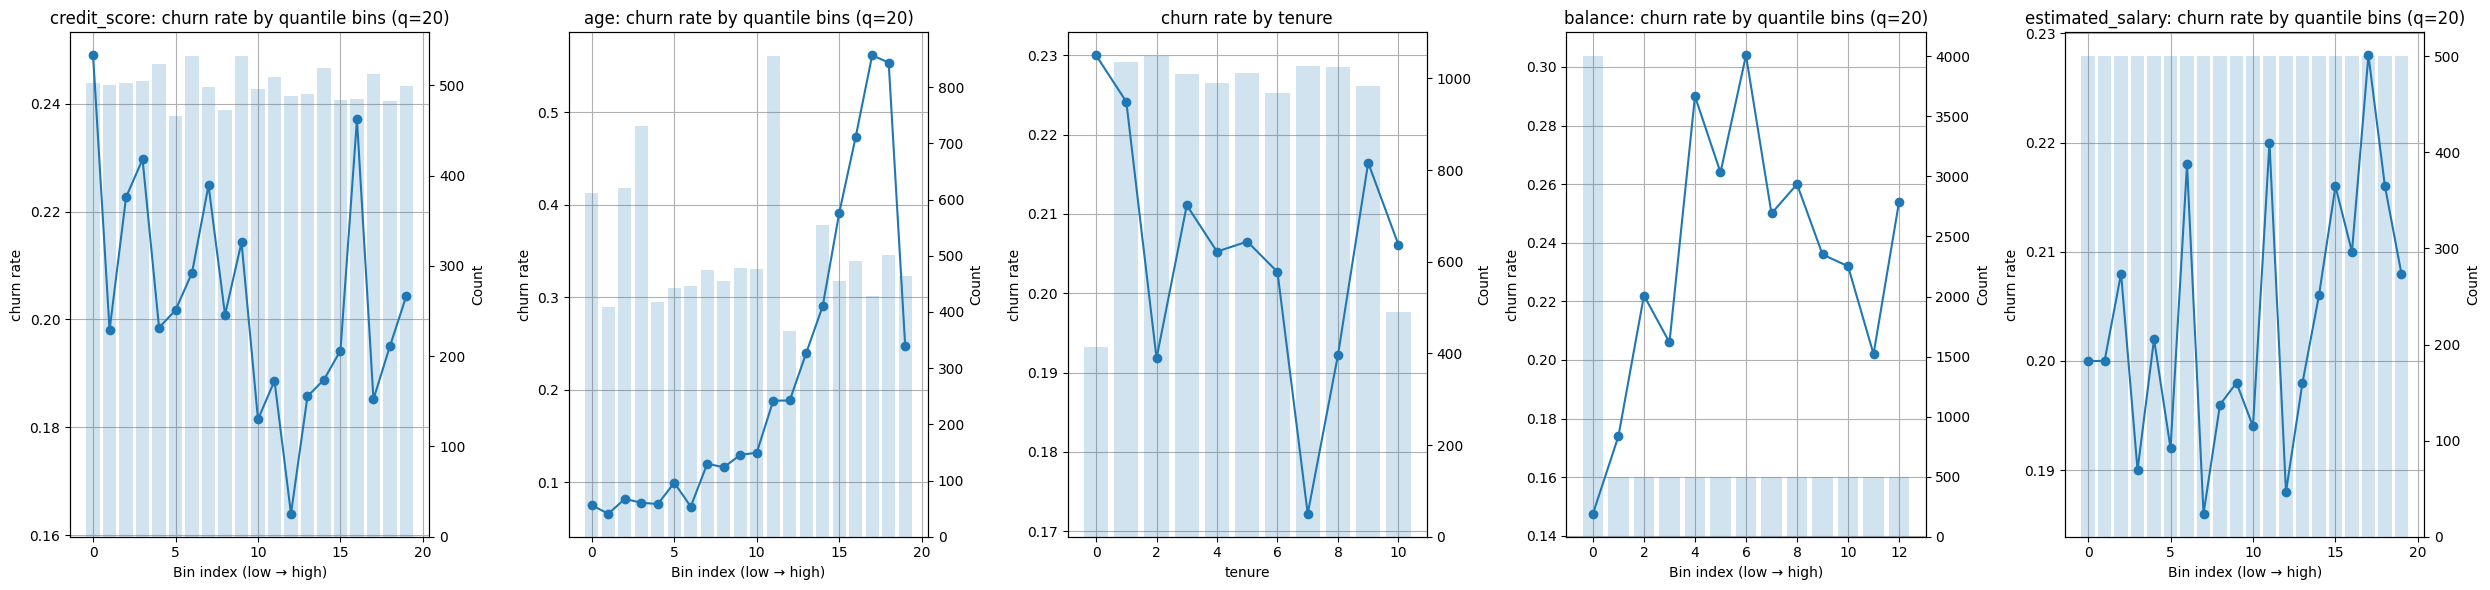

In [ ]:
target = "churn"
Q = 20  # số bins theo quantile

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    tmp = df_model[[col, target]].dropna().copy()
    ax = axes[i]

    nunique = tmp[col].nunique()

    if nunique <= 30:
        #Group theo từng giá trị của col trong num_cols tính tỷ lệ churn và số lượng trong nhóm
        stats = tmp.groupby(col)[target].agg(["mean","size"]).reset_index()
        x = stats[col].values           # Giá trị của từng cột
        rate = stats["mean"].values     # Tính tỷ lệ churn tương ứng từng giá trị trong mỗi cột
        cnt = stats["size"].values      ## Tính số lượng churn tương ứng từng giá trị trong mỗi cột

        # Vẽ đường line tỷ lệ churn
        ax.plot(x, rate, marker="o")
        ax.set_xlabel(col)
        ax.set_ylabel("churn rate")
        ax.set_title(f"churn rate by {col}")

        #Vẽ cột đếm số lượng
        ax2 = ax.twinx()
        ax2.bar(x, cnt, alpha=0.2)
        ax2.set_ylabel("Count")

    else:

        tmp["bin"] = pd.qcut(tmp[col], q=Q, duplicates="drop")
        stats = tmp.groupby("bin")[target].agg(["mean","size"])
        rate = stats["mean"].values
        cnt = stats["size"].values

        ax.plot(range(len(rate)), rate, marker="o")
        ax.set_title(f"{col}: churn rate by quantile bins (q={Q})")
        ax.set_ylabel("churn rate")
        ax.set_xlabel("Bin index (low → high)")

        ax2 = ax.twinx()
        ax2.bar(range(len(cnt)), cnt, alpha=0.2)
        ax2.set_ylabel("Count")

    ax.grid(True)

plt.tight_layout()
plt.show()

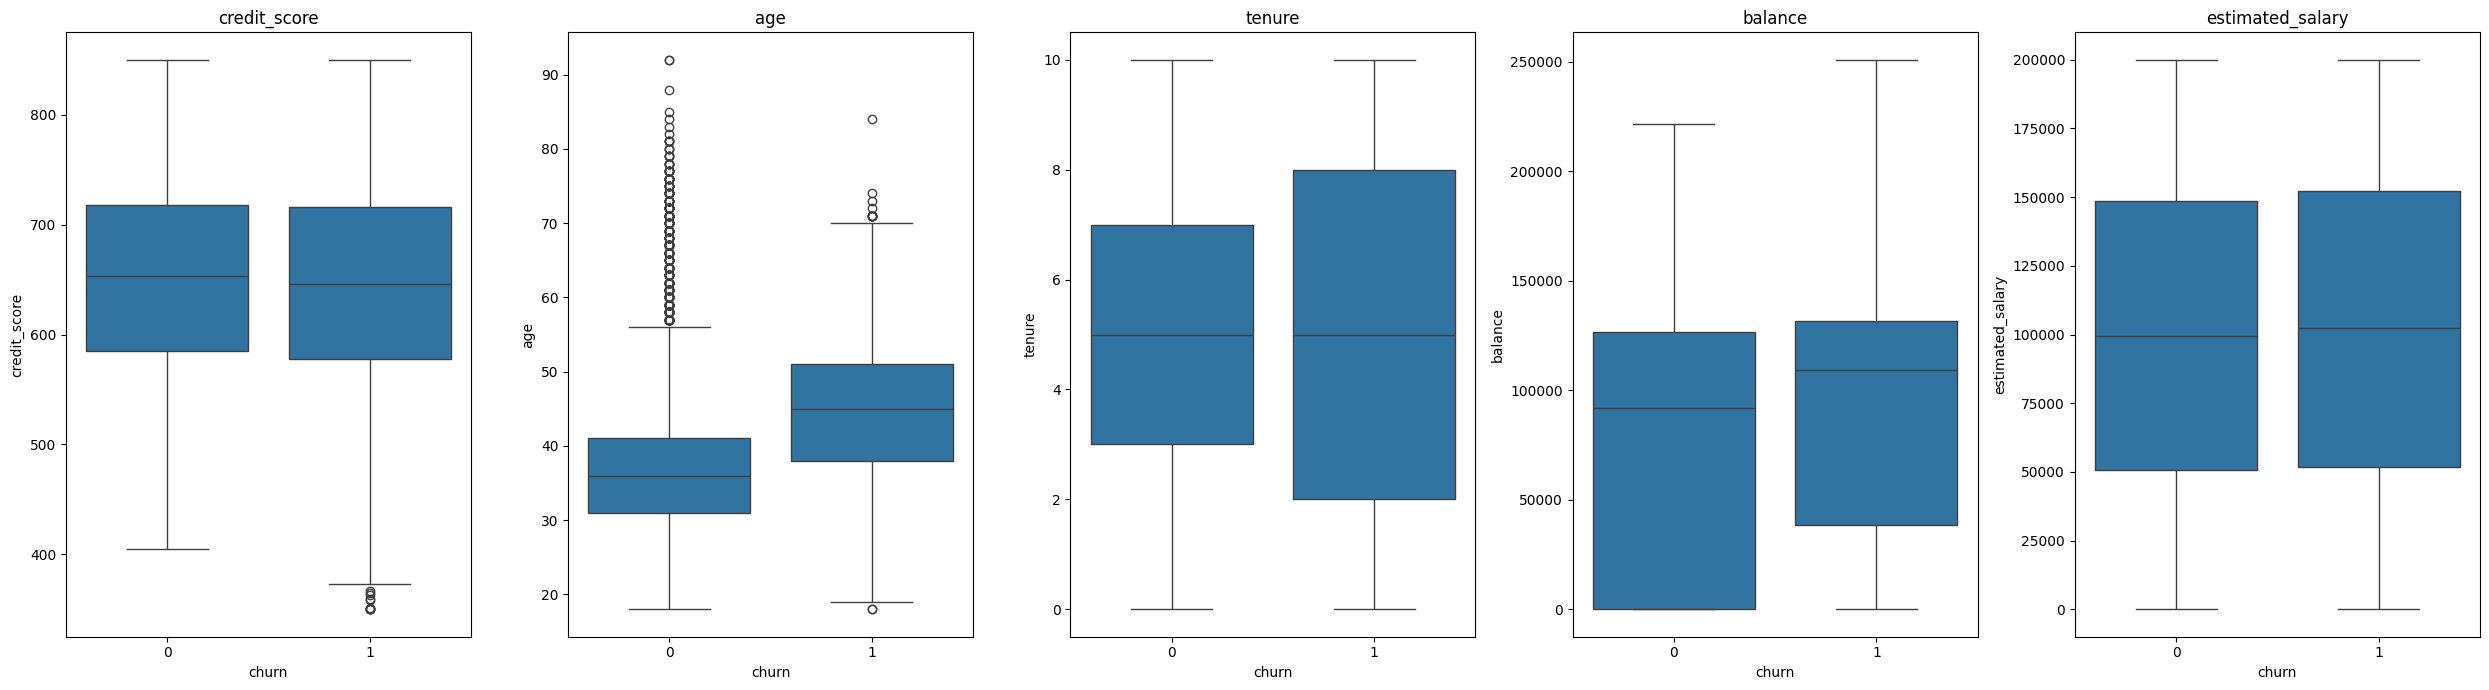

In [ ]:
cols_to_plot = [
    "credit_score", "age", "tenure", "balance", "estimated_salary"
]

fig, axes = plt.subplots(1, 5, figsize=(25,7))
axes = axes.ravel()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=df_model, x="churn", y=col, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


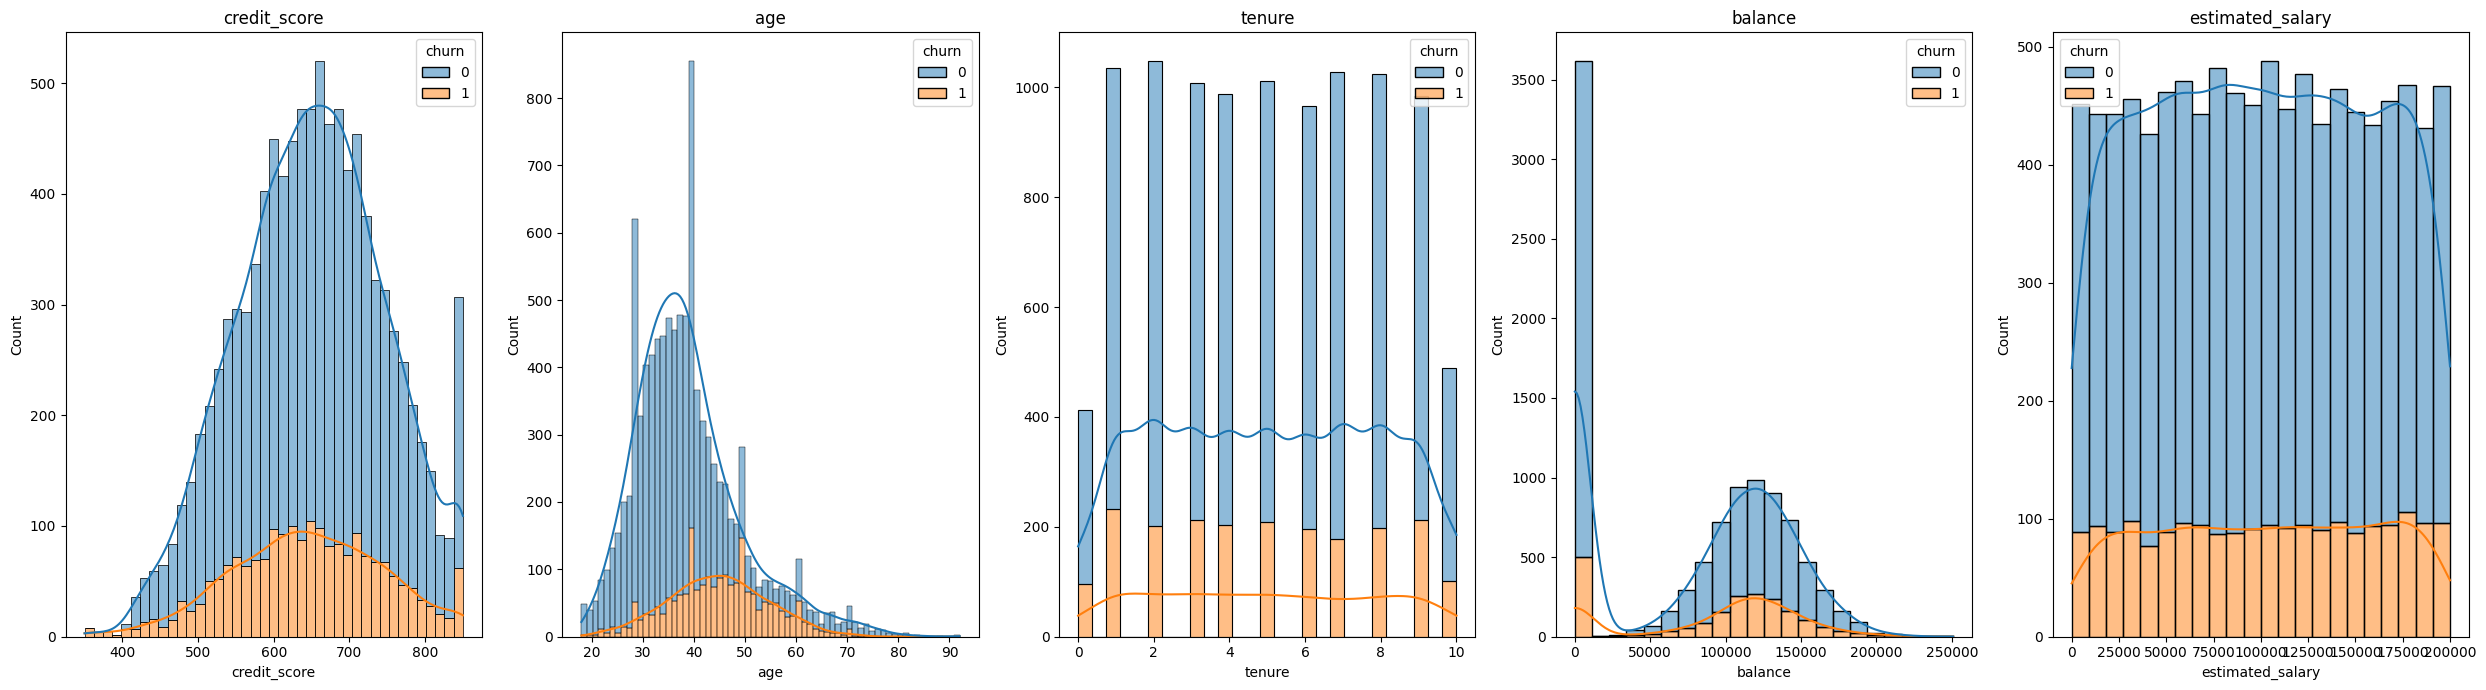

In [ ]:
fig, axes = plt.subplots(1,5,figsize=(25, 7))
axes = axes.ravel()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df_model, x=col, hue="churn",
        multiple="stack", kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


#Nhận xét:
1) Age

Ở hình churn rate theo quantile, đường age tăng rất rõ: nhóm tuổi thấp churn thấp, càng lớn tuổi churn càng cao (đặc biệt các bin tuổi cao vọt lên mạnh).

Boxplot age: median của churn=1 cao hơn churn=0 rõ rệt.

Histogram: nhóm 35 đên 55 churm cao

=> tuổi càng cao thì khả năng churn càng cao

2) Balance

Churn rate theo bin của balance nhìn chung cao hơn ở nhóm balance cao, nhưng dao động (không mượt) vì phân phối balance không đều.

Histogram balance cho thấy một cục rất lớn ở gần 0 (rất nhiều người balance 0) + một đỉnh khác quanh vùng 100k–150k.

Boxplot: nhóm churn=1 có median balance cao hơn churn=0.

=> balance cao có xu hướng churn cao hơn; và dữ liệu balance có kiểu nhiều giá trị 0

3) Credit_score:

Churn rate theo bin của credit_score lắc lư quanh 0.19–0.24, không có xu hướng tăng/giảm ổn định.

Boxplot credit_score: median 2 nhóm gần nhau.

Histogram credit_score: 2 phân phối chồng lên nhau nhiều.

=> credit_score không tách churn rõ

4) Estimated_salary:

Churn rate theo bin của estimated_salary gần như phẳng, chỉ dao động nhẹ.

Boxplot: median gần như nhau.

Histogram: phân phối churn=0/1 gần như trùng.

=> estimated_salary là feature yếu

5) Tenure:

Churn rate theo tenure giảm rồi tăng (không tuyến tính rõ), có điểm tụt mạnh quanh 7–8 rồi tăng lại.

Histogram tenure: các mức tenure khá đều

=>tenure có thể có ảnh hưởng nhưng không mạnh

#V/ TRAINING MÔ HÌNH

#1) Chia tập dữ liệu


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
y=df_model[target]

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state= 99)

#2) Preprocesing dữ liệu

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [ ]:
#Tạo pipeline cho feature thuộc cat_cols, chuẩn hoá dữ liệu cho mô hình dạng cây

Preprocessor=ColumnTransformer(transformers=[
    ("num", "passthrough", num_cols),
    ("cat2","passthrough",cat2_cols),
     ("cat",OneHotEncoder(handle_unknown="ignore") ,cat_cols)
])

#3) Training mô hình

## a) MÔ HÌNH DECISION TREE, RF

In [ ]:
# Oversampling (Random)
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(random_state=0)
# Oversampling (SMOKE - Nội suy thêm dữ liệu)
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=0)
# Oversampling (ADASYN - Dựa và các giá trị khó phân loại để tạo thêm dữ liệu)
from imblearn.over_sampling import ADASYN
ad = ADASYN(random_state=0)
# Combine (kết hợp Under Sampling + Oversampling SMOTETomek)
from imblearn.combine import SMOTETomek
smt = SMOTETomek(random_state=0)
# Combine (kết hợp Under Sampling + Oversampling SMOKEENN)
from imblearn.combine import SMOTEENN
smn = SMOTEENN(random_state=0)
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=0)



In [ ]:
# 5) Khởi mô hình và tunning mô hình
import time
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, accuracy_score, classification_report, confusion_matrix, precision_recall_curve

#
Sử dụng pipeline để train mô hình theo nhiều phương pháp cân bằng khác nhau
Thứ tự: tiền xử lý dữ liệu => Cân bằng dữ liệu=> mô hình

Sử dụng ImbPipeline (imbalanced-learn) để đảm bảo sampler chạy đúng trong CV: Mỗi fold: preprocess → sampler (chỉ trên train fold) → fit model

### TUNNING MÔ HÌNH DT TÌM SIÊU THAM SỐ

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

param_grid_dt = {
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [3, 5, 10, 20, None],
    "clf__min_samples_split": [2, 10, 50],
    "clf__min_samples_leaf": [1, 2, 4, 10],
}

pipes_tune = {

    "DT_balanced": ImbPipeline([("prep", Preprocessor),
                               ("clf", DecisionTreeClassifier(random_state=99, class_weight="balanced"))]),

    "DT_RandomOver": ImbPipeline([("prep", Preprocessor),
                                 ("sampler", RandomOverSampler(random_state=99)),
                                 ("clf", DecisionTreeClassifier(random_state=99))]),

    "DT_SMOTE": ImbPipeline([("prep", Preprocessor),
                             ("sampler", SMOTE(random_state=99)),
                             ("clf", DecisionTreeClassifier(random_state=99))]),

    "DT_Under": ImbPipeline([("prep", Preprocessor),
                             ("sampler", RandomUnderSampler(random_state=99)),
                             ("clf", DecisionTreeClassifier(random_state=99))]),


    "DT_SMOTEENN": ImbPipeline([("prep", Preprocessor),
                                ("sampler", SMOTEENN(random_state=99)),
                                ("clf", DecisionTreeClassifier(random_state=99))]),
}


best_params_by_method = {}
best_scores = {}
tune_summary = []

for name, pipe in pipes_tune.items():
    print(f"\n=== Tuning {name} ===")
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_dt,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1
    )
    start = time.time()
    gs.fit(X_train, y_train)
    t = time.time() - start

    best_params_by_method[name] = gs.best_params_
    tune_summary.append({
        "method": name,
        "cv_pr_auc": gs.best_score_,
        "time": t,
        "best_params": gs.best_params_
    })

tune_df = pd.DataFrame(tune_summary)
display(tune_df)



=== Tuning DT_balanced ===

=== Tuning DT_RandomOver ===

=== Tuning DT_SMOTE ===

=== Tuning DT_Under ===

=== Tuning DT_SMOTEENN ===


,method,cv_pr_auc,time,best_params
0,DT_balanced,0.621173,30.909856,"{'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 50}"
1,DT_RandomOver,0.611902,33.965501,"{'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 2}"
2,DT_SMOTE,0.622116,50.319536,"{'clf__criterion': 'gini', 'clf__max_depth': 10, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 50}"
3,DT_Under,0.583904,18.757584,"{'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 50}"
4,DT_SMOTEENN,0.593383,372.185115,"{'clf__criterion': 'entropy', 'clf__max_depth': 10, 'clf__min_samples_leaf': 10, 'clf__min_samples_split': 50}"


### TRAINING MÔ HÌNH DT VỚI KẾT QUẢ SIÊU THAM SỐ

In [ ]:
#1) Mô hình DT mặc định
dt_default = Pipeline(steps=[
    ("prep", Preprocessor),
    ("clf", DecisionTreeClassifier(random_state=99))
])

# 2) Model DT with balanced
dt_balanced = Pipeline(steps=[
    ("prep", Preprocessor),
    ("clf", DecisionTreeClassifier(
        random_state=99,
        class_weight="balanced",
        criterion="entropy",
        max_depth=10,
        min_samples_leaf=10,
        min_samples_split=50
    ))
])

# 3) Model with RandomOverSampler
dt_RandomOverSampler = ImbPipeline(steps=[
    ("prep", Preprocessor),
    ("sampler", RandomOverSampler(random_state=99)),
    ("clf", DecisionTreeClassifier(
        random_state=99,
        class_weight=None,
        criterion="entropy",
        max_depth=5,
        min_samples_leaf=10,
        min_samples_split=2
    ))
])
#4) Model with SMOTE
dt_SMOTE = ImbPipeline(steps=[
    ("prep", Preprocessor),
    ("sampler", SMOTE(random_state=99)),
    ("clf", DecisionTreeClassifier(
        random_state=99,
        class_weight=None,
        criterion="gini",
        max_depth=10,
        min_samples_leaf=10,
        min_samples_split=50
    ))
])

# 5) Model with RandomUnderSampler
dt_RandomUnderSampler = ImbPipeline(steps=[
    ("prep", Preprocessor),
    ("sampler", RandomUnderSampler(random_state=99)),
    ("clf", DecisionTreeClassifier(
        random_state=99,
        class_weight=None,
        criterion="entropy",
        max_depth=5,
        min_samples_leaf=10,
        min_samples_split=50
    ))
])

#6) Model with SMOTEENN
dt_SMOTEENN = ImbPipeline(steps=[
    ("prep", Preprocessor),
    ("sampler", SMOTEENN(random_state=99)),
    ("clf", DecisionTreeClassifier(
        random_state=99,
        class_weight=None,
        criterion="entropy",
        max_depth=10,
        min_samples_leaf=10,
        min_samples_split=50
    ))
])


In [ ]:
#List of model
model_list_dt={'DecisionTree_Default':dt_default,
            'DecisionTree_Balanced':dt_balanced,
            'DecisionTree_RandomOverSampler':dt_RandomOverSampler,
            'DecisionTree_SMOTE':dt_SMOTE,
            'DecisionTree_RandomUnderSampler':dt_RandomUnderSampler,
            'DecisionTree_SMOTEENN':dt_SMOTEENN
            }

In [ ]:
#Khởi tạo list data để ghi nhận kết quả training của mô hình
model_results_dt = []

Running model DecisionTree_Default


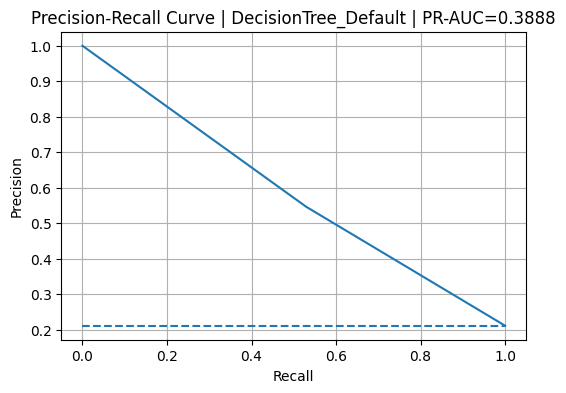

cn_matrix:
 [[1391  186]
 [ 199  224]]
Running model DecisionTree_Balanced


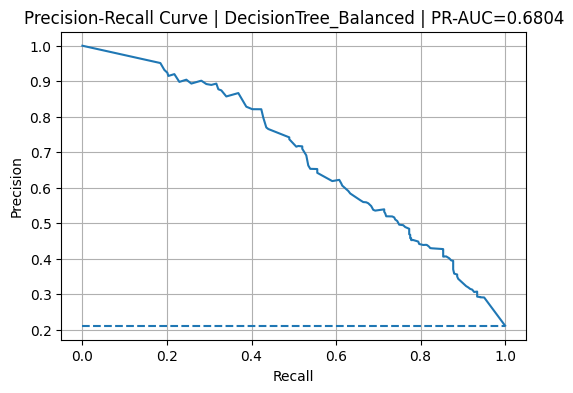

cn_matrix:
 [[1229  348]
 [  96  327]]
Running model DecisionTree_RandomOverSampler


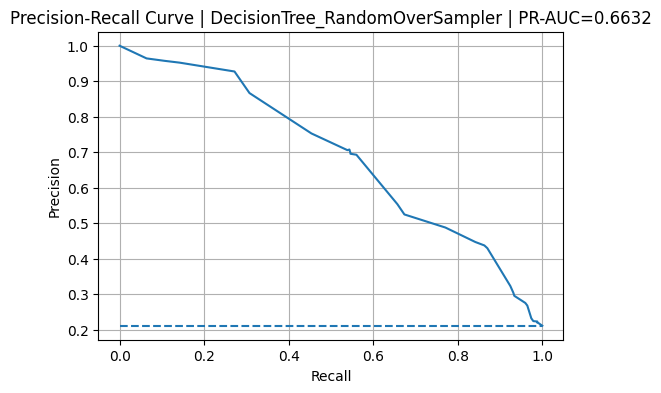

cn_matrix:
 [[1137  440]
 [  67  356]]
Running model DecisionTree_SMOTE


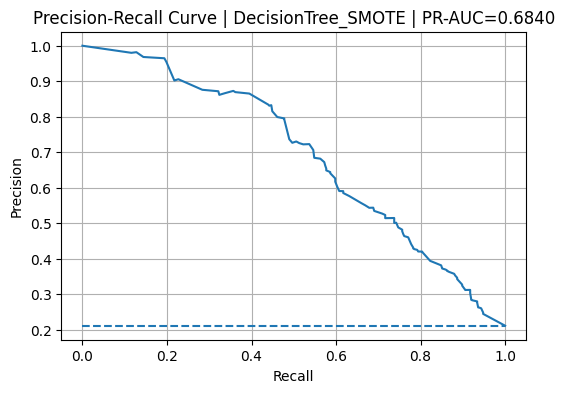

cn_matrix:
 [[1481   96]
 [ 192  231]]
Running model DecisionTree_RandomUnderSampler


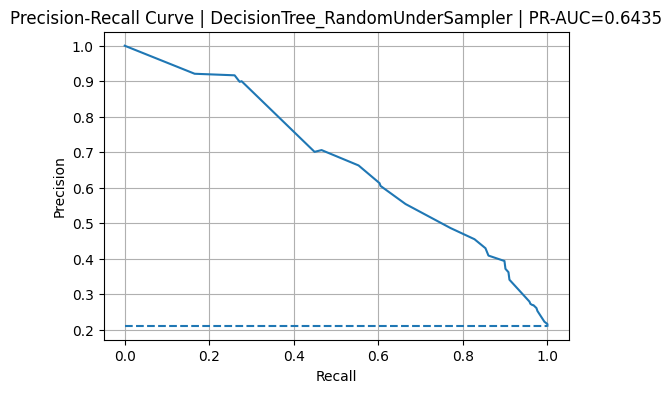

cn_matrix:
 [[1233  344]
 [  97  326]]
Running model DecisionTree_SMOTEENN


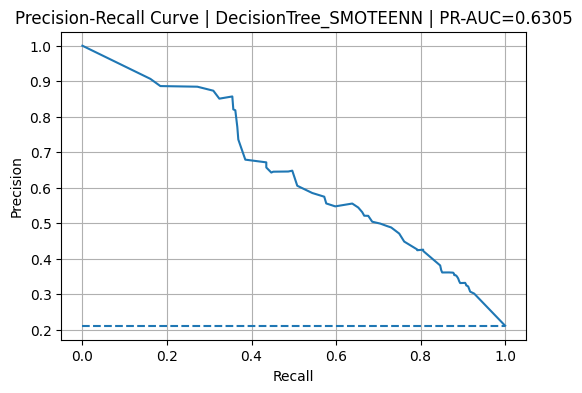

cn_matrix:
 [[1398  179]
 [ 181  242]]


In [ ]:
# Training và tính toán thông số đáng giá mô hình
for name_md, model in model_list_dt.items():
  print(f"Running model {name_md}")

  start_time = time.time()
  model.fit(X_train, y_train)
  take_time = (time.time() - start_time)

  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

  proba=model.predict_proba(X_test)[:, 1]
  y_pred = model.predict(X_test)

  # Tính toán các chỉ số
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  PR_AUC_score=average_precision_score(y_test, proba)

      # ===== PR curve =====
  pr_curve_prec, pr_curve_rec, threholds= precision_recall_curve(y_test, proba)

  plt.figure(figsize=(6,4))
  plt.plot(pr_curve_rec, pr_curve_prec)

  base = y_test.mean()
  plt.hlines(base, 0, 1, linestyles="--")

  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"Precision-Recall Curve | {name_md} | PR-AUC={ PR_AUC_score:.4f}")
  plt.grid(True)
  plt.show()


  print("cn_matrix:\n", confusion_matrix(y_test, y_pred))
  result = {
            "model": name_md,
            "PR-AUC": PR_AUC_score,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "take_time": take_time}

  model_results_dt.append(result)



In [ ]:
#Đánh giá mô hình
dt_model = pd.DataFrame(model_results_dt)
dt_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,DecisionTree_Default,0.388816,0.8075,0.546341,0.529551,0.537815,0.078948
1,DecisionTree_Balanced,0.680407,0.7780,0.484444,0.773050,0.595628,0.067824
2,DecisionTree_RandomOverSampler,0.663161,0.7465,0.447236,0.841608,0.584085,0.055557
3,DecisionTree_SMOTE,0.683959,0.8560,0.706422,0.546099,0.616000,0.116071
4,DecisionTree_RandomUnderSampler,0.643514,0.7795,0.486567,0.770686,0.596523,0.033695
5,DecisionTree_SMOTEENN,0.630477,0.8200,0.574822,0.572104,0.573460,1.020610


#Nhận xét:
- Matrix:

([[TN, FP],

[FN, TP]])

- DecisionTree_Default

Recall (bắt churn thật) = 0.529

Precision (dự đoán đúng churn) = 0.546

-> Cân bằng hơn, nhưng nếu mục tiêu ưu tiên muốn bắt churn hoặc ưu tiên dự đoán đúng churn thì không tối ưu


- DecisionTree_Balanced:

[1229, 348]

  [96, 327]

Recall (bắt churn thật) = 0.773 (cao)

Precision (dự đoán đúng churn) = 0.484 (thấp)

-> Bắt được nhiều churn nhưng báo nhầm khá nhiều.

- RandomOverSampler

[1137  440]

 [  67  356]

Recall (bắt churn thật) = 0.842 (cao)

Precision (dự đoán đúng churn) = 0.447 (thấp)

-> Recall cao nhất, nhưng việc báo nhầm cũng cao.

- DecisionTree_SMOTE:

 [1481, 96]

 [192, 231]

Recall (bắt churn thật) = 0.546 (trung bình)

Precision (dự đoán đúng churn) = 0.706  (cao)

-> Ít báo nhầm hơn rõ rệt, nhưng bắt đúng churn ở mức trung bình, củng bỏ sót khác nhiều

- RandomUnderSampler

[1481   96]

 [ 192  231]

Recall (bắt churn thật) = 0.792 (cao)

Precision (dự đoán đúng churn) = 0.460 (thấp)

-> Tương tự DecisionTree_Balanced, bắt được nhiều churn nhưng báo nhầm khá nhiều.

- DecisionTree_SMOTEENN:

[1398, 179]

[181, 242]

Recall (bắt churn thật) = 0.572

Precision (dự đoán đúng churn) = 0.575

-> Giống Default, Cân bằng hơn, nhưng nếu mục tiêu ưu tiên muốn bắt churn hoặc ưu tiên dự đoán đúng churn thì không tối ưu


=>Nhìn chung:

Mô hình DecisionTree_SMOTE là mô hình tối ưu hơn các mô hình khác khi cần dự đoán đún nhiều churn, ít báo nhầm churn

Mô hình DecisionTree_RandomOverSampler là mô hình bắt được nhiều churn nhất, phù hợp tiêu chí thà báo nhầm hơn bỏ sót

## TUNNING MÔ HÌNH RF

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

param_grid_rf={"clf__n_estimators": list(range(50, 351, 50)),
        "clf__max_depth": [None, 10, 20]}

pipes_tune = {

    "RF_balanced": ImbPipeline([("prep", Preprocessor),
                               ("clf", RandomForestClassifier(random_state=99, class_weight="balanced_subsample"))]),

    "RF_RandomOver": ImbPipeline([("prep", Preprocessor),
                                 ("sampler", RandomOverSampler(random_state=99)),
                                 ("clf", RandomForestClassifier(random_state=99))]),

    "RF_SMOTE": ImbPipeline([("prep", Preprocessor),
                             ("sampler", SMOTE(random_state=99)),
                             ("clf", RandomForestClassifier(random_state=99))]),

    "RF_Under": ImbPipeline([("prep", Preprocessor),
                             ("sampler", RandomUnderSampler(random_state=99)),
                             ("clf", RandomForestClassifier(random_state=99))]),


    "RF_SMOTEENN": ImbPipeline([("prep", Preprocessor),
                                ("sampler", SMOTEENN(random_state=99)),
                                ("clf", RandomForestClassifier(random_state=99))]),
}

best_params_by_method = {}
best_scores = {}
tune_summary = []

for name, pipe in pipes_tune.items():
    print(f"\n=== Tuning {name} ===")
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_rf,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1
    )
    start = time.time()
    gs.fit(X_train, y_train)
    t = time.time() - start


    best_params_by_method[name] = gs.best_params_
    tune_summary.append({
        "method": name,
        "cv_pr_auc": gs.best_score_,
        "time": t,
        "best_params": gs.best_params_
    })

tune_rf = pd.DataFrame(tune_summary)
display(tune_rf)




=== Tuning RF_balanced ===

=== Tuning RF_RandomOver ===

=== Tuning RF_SMOTE ===

=== Tuning RF_Under ===

=== Tuning RF_SMOTEENN ===


,method,cv_pr_auc,time,best_params
0,RF_balanced,0.662793,216.954233,"{'clf__max_depth': 10, 'clf__n_estimators': 250}"
1,RF_RandomOver,0.662581,239.284777,"{'clf__max_depth': 10, 'clf__n_estimators': 350}"
2,RF_SMOTE,0.668090,306.944470,"{'clf__max_depth': 10, 'clf__n_estimators': 150}"
3,RF_Under,0.650617,94.834285,"{'clf__max_depth': 10, 'clf__n_estimators': 300}"
4,RF_SMOTEENN,0.643096,204.545583,"{'clf__max_depth': 10, 'clf__n_estimators': 100}"


## TRAINING MÔ HÌNH RF VỚI SIÊU THAM SỐ

In [ ]:
#1)Mô hình RF mặc định
rf_default = Pipeline(steps=[
    ("prep", Preprocessor),
    ("clf", RandomForestClassifier(random_state=99))
])

# 2) Model RF with balanced
rf_balanced = Pipeline(steps=[
    ("prep", Preprocessor),
    ("clf", RandomForestClassifier(
        random_state=99,
        class_weight="balanced_subsample",
        max_depth=10,
        n_estimators=250
    ))
])

# 3) Model with RandomOverSampler
rf_RandomOverSampler = ImbPipeline(steps=[
    ("prep", Preprocessor),
    ("sampler", RandomOverSampler(random_state=99)),
    ("clf",  RandomForestClassifier(
        random_state=99,
        class_weight=None,
        max_depth=10,
        n_estimators=350
    ))
])
#4)#2)Model with SMOTE
rf_SMOTE = ImbPipeline(steps=[
    ("prep", Preprocessor),
    ("sampler", SMOTE(random_state=99)),
    ("clf",  RandomForestClassifier(
        random_state=99,
        class_weight=None,
        max_depth=10,
        n_estimators=150
    ))
])

# 5) Model with RandomUnderSampler
rf_RandomUnderSampler = ImbPipeline(steps=[
    ("prep", Preprocessor),
    ("sampler", RandomUnderSampler(random_state=99)),
    ("clf",  RandomForestClassifier(
        random_state=99,
        class_weight=None,
        max_depth=10,
        n_estimators=300
    ))
])

# 6) Model with SMOTEENN
rf_SMOTEENN = ImbPipeline(steps=[
    ("prep", Preprocessor),
    ("sampler", SMOTEENN(random_state=99)),
    ("clf",  RandomForestClassifier(
        random_state=99,
        class_weight=None,
        max_depth=10,
        n_estimators=100
    ))
])

In [ ]:
#List of model
model_list_rf={'RF_Default':rf_default,
            'RF_Balanced':rf_balanced,
            'RF_RandomOverSampler':rf_RandomOverSampler,
            'RF_SMOTE':rf_SMOTE,
            'RF_RandomUnderSampler':rf_RandomUnderSampler,
            'RF_SMOTEENN':rf_SMOTEENN
            }

In [ ]:
#Khởi tạo list data để ghi nhận kết quả training của mô hình
model_results_rf = []

Running model RF_Default


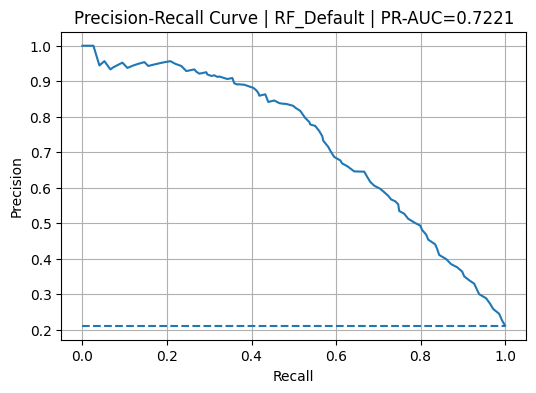

cn_matrix:
 [[1532   45]
 [ 210  213]]
Running model RF_Balanced


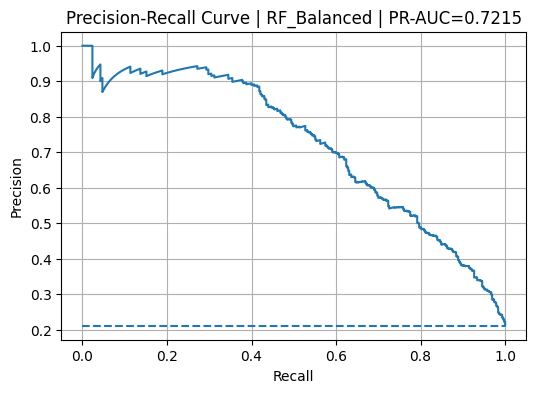

cn_matrix:
 [[1385  192]
 [ 134  289]]
Running model RF_RandomOverSampler


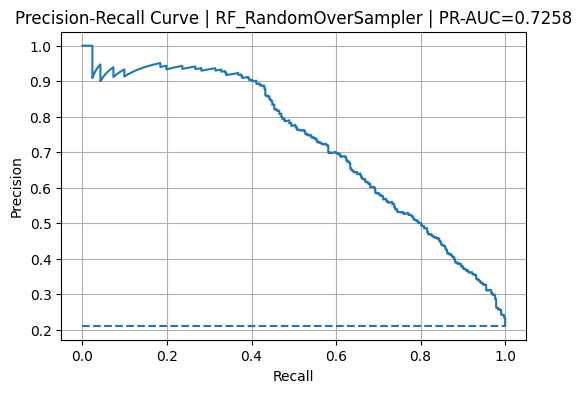

cn_matrix:
 [[1341  236]
 [ 119  304]]
Running model RF_SMOTE


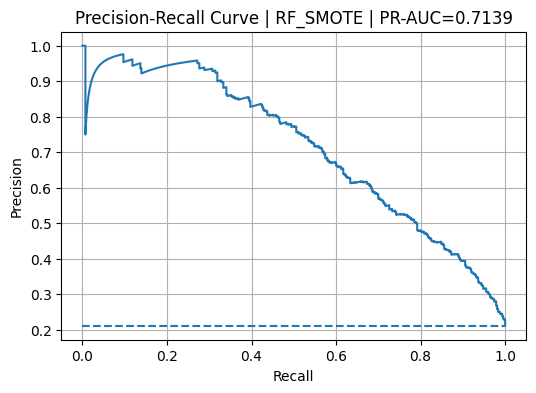

cn_matrix:
 [[1486   91]
 [ 191  232]]
Running model RF_RandomUnderSampler


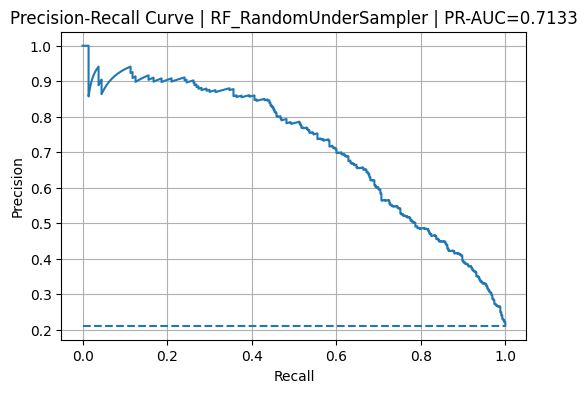

cn_matrix:
 [[1247  330]
 [  91  332]]
Running model RF_SMOTEENN


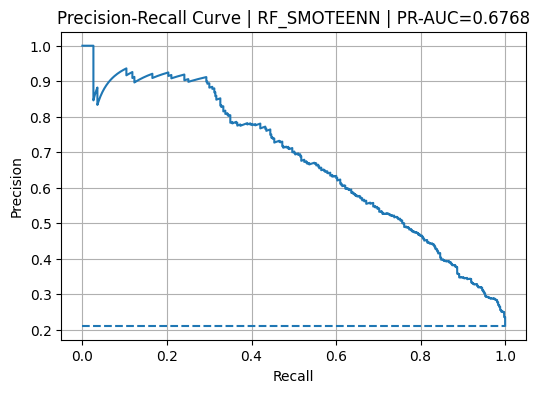

cn_matrix:
 [[1449  128]
 [ 184  239]]


In [ ]:
# Training và tính toán thông số đáng giá mô hình
for name_md, model_rf in model_list_rf.items():
  print(f"Running model {name_md}")

  start_time = time.time()
  model_rf.fit(X_train, y_train)
  take_time = (time.time() - start_time)

  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

  proba=model_rf.predict_proba(X_test)[:, 1]
  y_pred = model_rf.predict(X_test)

  # Tính toán các chỉ số
  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  PR_AUC_score=average_precision_score(y_test, proba)

   # ===== PR curve =====
  pr_curve_prec, pr_curve_rec, threholds= precision_recall_curve(y_test, proba)

  plt.figure(figsize=(6,4))
  plt.plot(pr_curve_rec, pr_curve_prec)

  base = y_test.mean()
  plt.hlines(base, 0, 1, linestyles="--")

  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"Precision-Recall Curve | {name_md} | PR-AUC={ PR_AUC_score:.4f}")
  plt.grid(True)
  plt.show()

  print("cn_matrix:\n", confusion_matrix(y_test, y_pred))
  result = {
            "model": name_md,
            "PR-AUC": PR_AUC_score,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "take_time": take_time}

  model_results_rf.append(result)

In [ ]:
#Đánh giá mô hình
rf_model = pd.DataFrame(model_results_rf)
rf_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,RF_Default,0.722137,0.8725,0.825581,0.503546,0.625551,1.398125
1,RF_Balanced,0.721509,0.8370,0.600832,0.683215,0.639381,3.195953
2,RF_RandomOverSampler,0.725848,0.8225,0.562963,0.718676,0.631360,5.511887
3,RF_SMOTE,0.713918,0.8590,0.718266,0.548463,0.621984,2.870224
4,RF_RandomUnderSampler,0.713315,0.7895,0.501511,0.784870,0.611982,1.606579
5,RF_SMOTEENN,0.676830,0.8440,0.651226,0.565012,0.605063,2.065672


#Nhận xét:
- PR-AUC: OverSampler, Default , Balanced gần như ngang nhau.

- RF_Default

Recall (bắt churn thật) = 0.5

Precision (dự đoán đúng churn) = 0.83


RF_Balanced:


Recall (bắt churn thật) = 0.68

Precision (dự đoán đúng churn) = 0.6


- RF_RandomOverSampler


Recall (bắt churn thật) = 0.72

Precision (dự đoán đúng churn) = 0.56



- RF_SMOTE:

Recall (bắt churn thật) = 0.54

Precision (dự đoán đúng churn) = 0.71  



- RF_RandomUnderSampler

Recall (bắt churn thật) = 0.78 (cao)

Precision (dự đoán đúng churn) = 0.5 (thấp)



- RF_SMOTEENN:

Recall (bắt churn thật) = 0.56

Precision (dự đoán đúng churn) = 0.65



=> Kết luận:

Tương tự phân tích các chỉ số của Decision Tree ở trên:

Mô hình dự đoán đúng nhiều churn, ít báo nhầm churn (Prcision cao): RF_Default, RF_SMOTE (default ít tốn thời gian hơn)

Mô hình bắt được nhiều churn và ít bị bỏ sót (recall cao): RF_RandomUnderSampler, RF_RandomOverSampler (under ít tốn thời gian hơn)

Mô hình cân bằng hơn: RF_Balanced (cân bằng tốt giữa precision và recall)

## b/ MÔ HÌNH LR

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [ ]:
#Scale dữ liệu train

Preprocessor_lr=ColumnTransformer(transformers=[
    ("num", StandardScaler(), num_cols),
    ("cat2_cols", "passthrough", cat2_cols),
    ( "cat",OneHotEncoder(handle_unknown="ignore") ,cat_cols)
])

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=99)

param_grid_lr = {
    "clf__C": [0.01, 0.1, 1.0, 3.0, 10.0],
    "clf__penalty": ["l1", "l2"],
    "clf__class_weight": [None, "balanced"]
}

pipes_tune = {

    "LR_no_resample": ImbPipeline([("prep", Preprocessor_lr),
                               ("clf", LogisticRegression(random_state=99,solver="saga",max_iter=5000))]),

    "LR_RandomOver": ImbPipeline([("prep", Preprocessor_lr),
                                 ("sampler", RandomOverSampler(random_state=99)),
                                 ("clf", LogisticRegression(random_state=99,solver="saga",max_iter=5000))]),

    "LR_SMOTE": ImbPipeline([("prep", Preprocessor_lr),
                             ("sampler", SMOTE(random_state=99)),
                             ("clf", LogisticRegression(random_state=99,solver="saga",max_iter=5000))]),

    "LR_Under": ImbPipeline([("prep", Preprocessor_lr),
                             ("sampler", RandomUnderSampler(random_state=99)),
                             ("clf", LogisticRegression(random_state=99,solver="saga",max_iter=5000))]),


    "LR_SMOTEENN": ImbPipeline([("prep", Preprocessor_lr),
                                ("sampler", SMOTEENN(random_state=99)),
                                ("clf", LogisticRegression(random_state=99,solver="saga",max_iter=5000))]),
}

best_params_by_method = {}
best_scores = {}
tune_summary = []

for name, pipe in pipes_tune.items():
    print(f"\n=== Tuning {name} ===")
    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid_lr,
        scoring="average_precision",
        cv=cv,
        n_jobs=-1
    )
    start = time.time()
    gs.fit(X_train, y_train)
    t = time.time() - start

    best_params_by_method[name] = gs.best_params_
    tune_summary.append({
        "method": name,
        "cv_pr_auc": gs.best_score_,
        "time": t,
        "best_params": gs.best_params_
    })

tune_lr = pd.DataFrame(tune_summary)
display(tune_lr)




=== Tuning LR_no_resample ===

=== Tuning LR_RandomOver ===

=== Tuning LR_SMOTE ===

=== Tuning LR_Under ===

=== Tuning LR_SMOTEENN ===


,method,cv_pr_auc,time,best_params
0,LR_no_resample,0.610220,41.509916,"{'clf__C': 10.0, 'clf__class_weight': None, 'clf__penalty': 'l2'}"
1,LR_RandomOver,0.605434,76.574818,"{'clf__C': 10.0, 'clf__class_weight': None, 'clf__penalty': 'l1'}"
2,LR_SMOTE,0.607436,204.452397,"{'clf__C': 10.0, 'clf__class_weight': None, 'clf__penalty': 'l2'}"
3,LR_Under,0.602495,19.814183,"{'clf__C': 10.0, 'clf__class_weight': None, 'clf__penalty': 'l1'}"
4,LR_SMOTEENN,0.605705,199.911108,"{'clf__C': 10.0, 'clf__class_weight': 'balanced', 'clf__penalty': 'l1'}"


In [ ]:
# Training và tính toán thông số đáng giá mô hình
lr_default=Pipeline(steps=[
    ("prep", Preprocessor_lr),
    ("clf", LogisticRegression(
        random_state=99,
        max_iter=5000)
)])

lr_no_resample=Pipeline(steps=[
    ("prep", Preprocessor_lr),
    ("clf", LogisticRegression(
        random_state=99,solver="saga",
        max_iter=5000,
        class_weight=None,
        C=10,
        penalty="l2",
        )
)])

lr_smote=ImbPipeline(steps=[
    ("prep", Preprocessor_lr),
    ("sampler", SMOTE(random_state=99)),
    ("clf", LogisticRegression(
        random_state=99,solver="saga",
        max_iter=5000,
        class_weight=None,
        C=10,
        penalty="l2",
        )
)])

lr_random_over=ImbPipeline(steps=[
    ("prep", Preprocessor_lr),
    ("sampler", RandomOverSampler(random_state=99)),
    ("clf", LogisticRegression(
        random_state=99,solver="saga",
        max_iter=5000,
        class_weight=None,
        C=10,
        penalty="l1",
        )
)])

lr_random_under=ImbPipeline(steps=[
    ("prep", Preprocessor_lr),
    ("sampler", RandomUnderSampler(random_state=99)),
    ("clf", LogisticRegression(
        random_state=99,solver="saga",
        max_iter=5000,
        class_weight=None,
        C=10,
        penalty="l1",
        )
)])


lr_Smotenn=ImbPipeline(steps=[
    ("prep", Preprocessor_lr),
    ("sampler", SMOTEENN(random_state=99)),
    ("clf", LogisticRegression(
        random_state=99,solver="saga",
        max_iter=5000,
        class_weight="balanced",
        C=10,
        penalty="l1",
        )
)])



In [ ]:
model_list_lr = {
    "logisticRegression": lr_default,
    "LR_no_sample": lr_no_resample,
    "LR_SMOTE": lr_smote,
    "LR_RandomOverSampler": lr_random_over,
    "LR_RandomUnderSampler": lr_random_under,
    "LR_SMOTEENN": lr_Smotenn
}

In [ ]:
# Khởi tạo list data để ghi nhận kết quả training của mô hình
model_results_lr = []

Running model logisticRegression


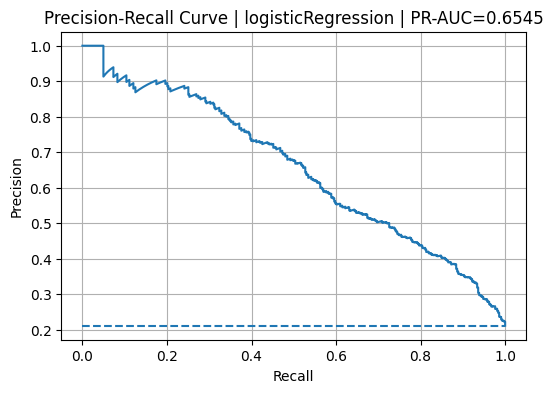

cn_matrix:
 [[1527   50]
 [ 261  162]]
Running model LR_no_sample


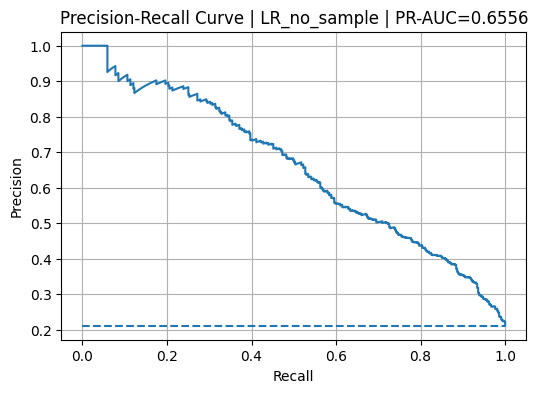

cn_matrix:
 [[1527   50]
 [ 262  161]]
Running model LR_SMOTE


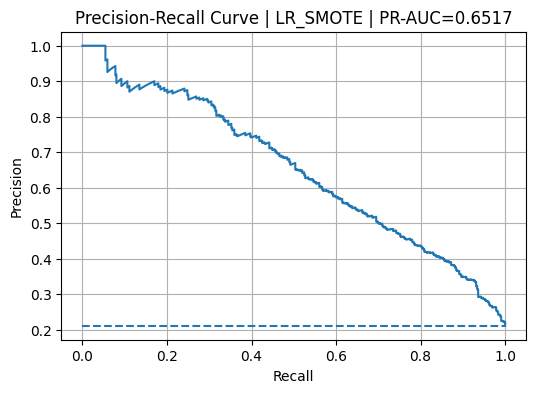

cn_matrix:
 [[1198  379]
 [ 101  322]]
Running model LR_RandomOverSampler


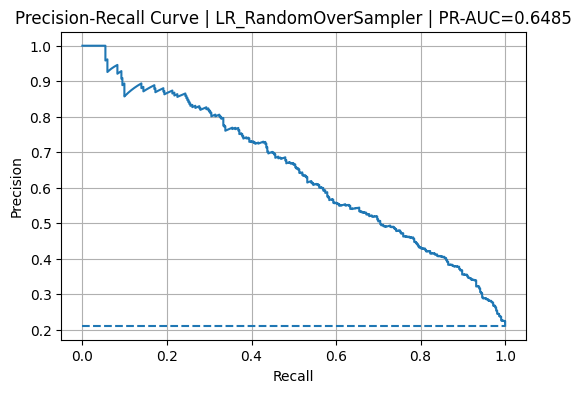

cn_matrix:
 [[1193  384]
 [  96  327]]
Running model LR_RandomUnderSampler


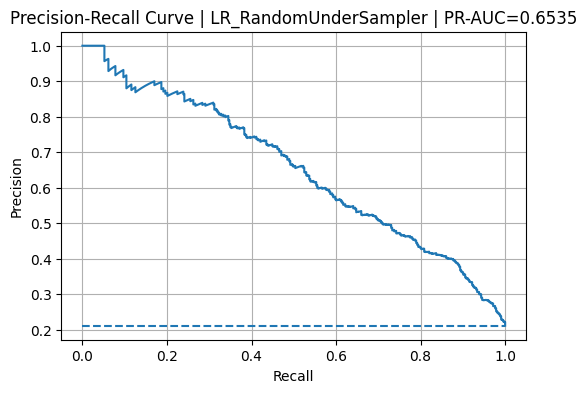

cn_matrix:
 [[1201  376]
 [  99  324]]
Running model LR_SMOTEENN


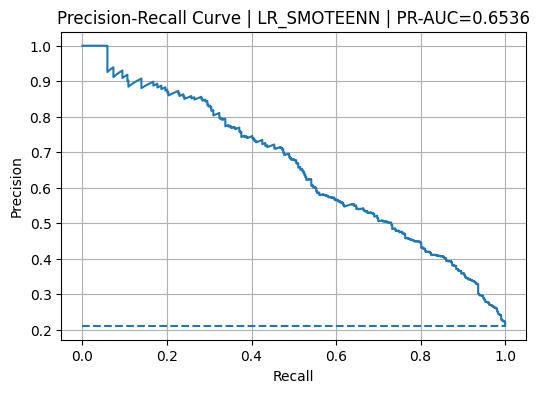

cn_matrix:
 [[1130  447]
 [  84  339]]


In [ ]:
# Khời tạo vòng lặp training và ghi nhận kết quả mô hình

for name_md, model_lr in model_list_lr.items():
  print(f"Running model {name_md}")

  start_time = time.time()
  model_lr.fit(X_train, y_train)
  take_time = (time.time() - start_time)


  from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

  # Dự đoán y
  proba=model_lr.predict_proba(X_test)[:, 1]
  y_pred = model_lr.predict(X_test)

  # Tính toán các chỉ số

  accuracy = accuracy_score(y_test, y_pred)
  precision = precision_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  PR_AUC_score=average_precision_score(y_test, proba)

   # ===== PR curve =====
  pr_curve_prec, pr_curve_rec, threholds= precision_recall_curve(y_test, proba)

  plt.figure(figsize=(6,4))
  plt.plot(pr_curve_rec, pr_curve_prec)

  base = y_test.mean()
  plt.hlines(base, 0, 1, linestyles="--")

  plt.xlabel("Recall")
  plt.ylabel("Precision")
  plt.title(f"Precision-Recall Curve | {name_md} | PR-AUC={ PR_AUC_score:.4f}")
  plt.grid(True)
  plt.show()

  print("cn_matrix:\n", confusion_matrix(y_test, y_pred))
  result = {
            "model": name_md,
            "PR-AUC": PR_AUC_score,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "take_time": take_time}

  model_results_lr.append(result)

In [ ]:
#Đánh giá mô hình
lr_model = pd.DataFrame(model_results_lr)
lr_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,logisticRegression,0.654545,0.8445,0.764151,0.382979,0.510236,0.050219
1,LR_no_sample,0.655569,0.8440,0.763033,0.380615,0.507886,1.225368
2,LR_SMOTE,0.651744,0.7600,0.459344,0.761229,0.572954,2.859988
3,LR_RandomOverSampler,0.648536,0.7600,0.459916,0.773050,0.576720,2.266317
4,LR_RandomUnderSampler,0.653465,0.7625,0.462857,0.765957,0.577026,0.544290
5,LR_SMOTEENN,0.653638,0.7345,0.431298,0.801418,0.560794,9.003703


#Nhận xét:
- PR-AUC: các mô hình đểu tương đương nhau

- LogisticRegression:

Recall (bắt churn thật) = 0.38

Precision (dự đoán đúng churn) = 0.76


LR_no_sample:


Recall (bắt churn thật) = 0.38

Precision (dự đoán đúng churn) = 0.76


- LR_SMOTE:


Recall (bắt churn thật) = 0.76

Precision (dự đoán đúng churn) = 0.45



- LR_RandomoverSampler:

Recall (bắt churn thật) = 0.77

Precision (dự đoán đúng churn) = 0.45



- LR_RandomUnderSampler

Recall (bắt churn thật) = 0.76

Precision (dự đoán đúng churn) = 0.46



- LR_SMOTEENN:

Recall (bắt churn thật) = 0.8

Precision (dự đoán đúng churn) = 0.43



=> Kết luận:

Mô hình dự đoán đúng nhiều churn, ít báo nhầm churn (Prcision cao): LogisticRegression(LR_default), LR_no_sample
Mô hình bắt được nhiều churn và ít bị bỏ sót (recall cao): LR_SMOTE, LR_RandomoverSampler,LR_RandomUnderSampler,LR_SMOTEENN



# ĐÁNH GIÁ VAI TRÒ CÁC BIẾN

In [ ]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import numpy as np

## a) Đánh giá biến của mô hình DT

In [ ]:
#Lấy model tốt nhất theo PR-AUC từ bảng kết quả
res_df = pd.DataFrame(model_results_dt)
best_name_dt = res_df.sort_values("PR-AUC", ascending=False).iloc[0]["model"]
print("Best model DT:", best_name_dt)

Best model DT: DecisionTree_SMOTE


In [ ]:
#Lấy  model tương ứng
best_model_dt = model_list_dt[best_name_dt]

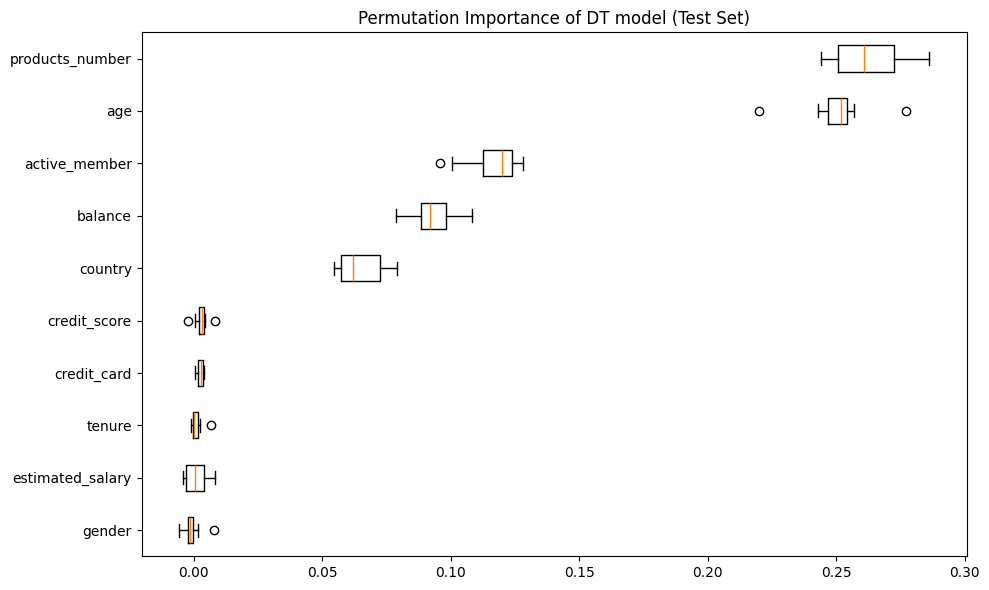

In [ ]:

# Đảm bảo best_dt_model, X_test và y_test được định nghĩa
if 'best_model_dt' in locals() and 'X_test' in locals() and 'y_test' in locals():
# Tính toán Permutation Importance
    result = permutation_importance(
        best_model_dt, X_test, y_test, n_repeats=10,scoring="average_precision", random_state=0, n_jobs=-1
    )
    # Sắp xếp các biến theo mức độ quan trọng
    sorted_idx = result.importances_mean.argsort()
    # Vẽ biểu đồ Permutation Importance
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        tick_labels=X_test.columns[sorted_idx],
    )
    ax.set_title("Permutation Importance of DT model (Test Set)")
    fig.tight_layout()
    plt.show()
else:
    print("Các biến cần thiết (best_dt_model, X_test, y_test) không tìm thấy. Vui lòng chạy các ô trước đó.")

## b) Đánh gía biến cảu mô hình RF

In [ ]:
#Lấy model tốt nhất theo PR-AUC từ bảng kết quả
res_df = pd.DataFrame(model_results_rf)
best_name_rf = res_df.sort_values("PR-AUC", ascending=False).iloc[0]["model"]
print("Best model RF:", best_name_rf)

Best model RF: RF_RandomOverSampler


In [ ]:
#Lấy  model tương ứng
best_model_rf = model_list_rf[best_name_rf]

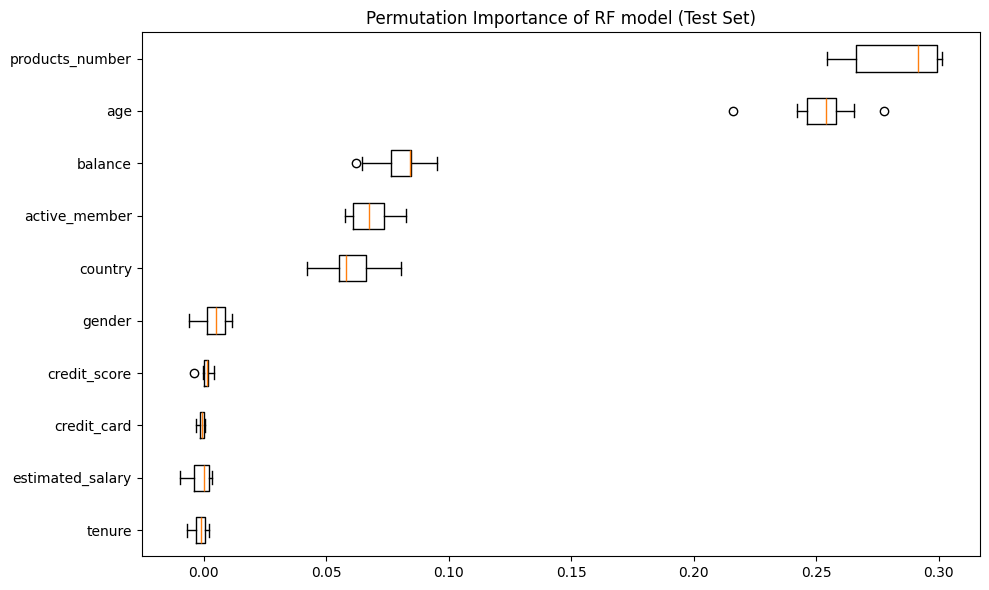

In [ ]:
# Đảm bảo best_dt_model, X_test và y_test được định nghĩa
if 'best_model_rf' in locals() and 'X_test' in locals() and 'y_test' in locals():
    # Tính toán Permutation Importance
    result = permutation_importance(
        best_model_rf, X_test, y_test, n_repeats=10,scoring="average_precision", random_state=0, n_jobs=-1
    )
    # Sắp xếp các biến theo mức độ quan trọng
    sorted_idx = result.importances_mean.argsort()
    # Vẽ biểu đồ Permutation Importance
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        tick_labels=X_test.columns[sorted_idx],
    )
    ax.set_title("Permutation Importance of RF model (Test Set)")
    fig.tight_layout()
    plt.show()
else:
    print("Các biến cần thiết (best_dt_model, X_test, y_test) không tìm thấy. Vui lòng chạy các ô trước đó.")

## c) ĐÁnh giá biến của mô hình LR

In [ ]:
#Lấy model tốt nhất theo PR-AUC từ bảng kết quả
res_df = pd.DataFrame(model_results_lr)
best_name_lr = res_df.sort_values("PR-AUC", ascending=False).iloc[0]["model"]
print("Best model LR:", best_name_lr)

Best model LR: LR_no_sample


In [ ]:
#Lấy  model tương ứng
best_model_lr = model_list_lr[best_name_lr]

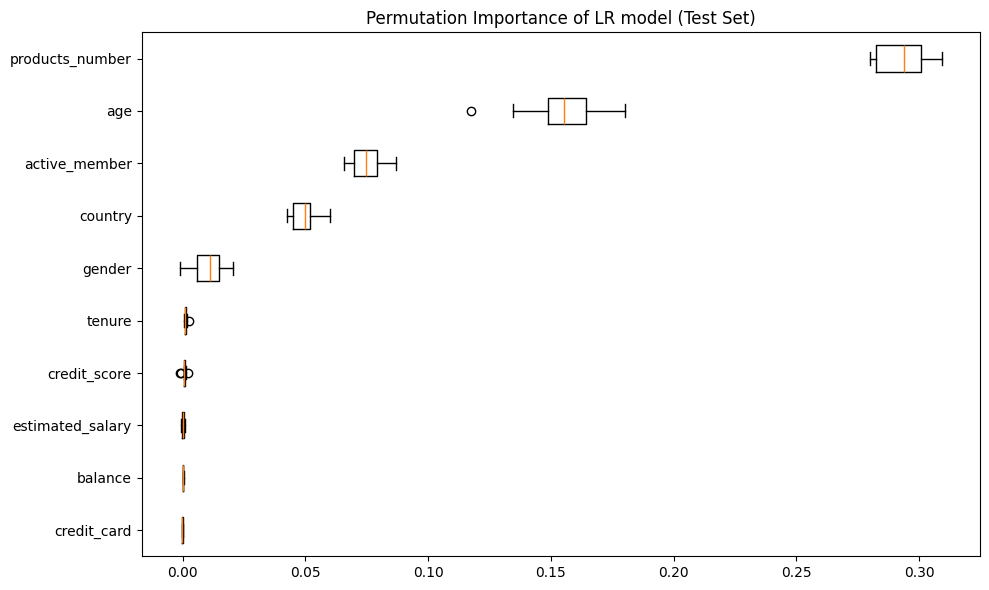

In [ ]:
# Đảm bảo best_dt_model, X_test và y_test được định nghĩa
if 'best_model_lr' in locals() and 'X_test' in locals() and 'y_test' in locals():
    # Tính toán Permutation Importance
    result = permutation_importance(
        best_model_lr, X_test, y_test, n_repeats=10,scoring="average_precision", random_state=0, n_jobs=-1
    )
    # Sắp xếp các biến theo mức độ quan trọng
    sorted_idx = result.importances_mean.argsort()
    # Vẽ biểu đồ Permutation Importance
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.boxplot(
        result.importances[sorted_idx].T,
        vert=False,
        tick_labels=X_test.columns[sorted_idx],
    )
    ax.set_title("Permutation Importance of LR model (Test Set)")
    fig.tight_layout()
    plt.show()
else:
    print("Các biến cần thiết (best_dt_model, X_test, y_test) không tìm thấy. Vui lòng chạy các ô trước đó.")

#Nhận xét:
Các biến quan trọng: products_number, age, active_member.

Các yếu tố mức trung bình/tuỳ mô hình: country, balance

Các biến đóng góp thấp: estimated_salary, tenure, credit_card.



#REPORT
Phần trên là các code và EDA từng phần, sau đây là phần báo cáo tổng quát
1) MÔ HÌNH KHUYẾN NGHỊ

- Mục tiêu bài toán là dự đoán khách hàng rời bỏ (churn). Dữ liệu này khá mất cân bằng lớp (churn chiếm tỷ lệ thấp hơn nhiều so với non-churn).Do đó chúng ta có thể dựa vào chỉ số PR-AUC, kết hợp cùng recall và F1-score để có thể phát hiện tốt nhất khách hàng có nguy cơ rời bỏ(xem các kết quả model ở trên)

### Đánh gía mô hình tối ưu dựa vào chỉ số PR-AUC

- Phần trên thử nghiệm các model DT,RF,LR với các phương pháp xử lý mất cân bằng khác nhau thì mỗi dạng model lấy ra được các model tối ưu sau: DecisionTree_SMOTE,RF_balance,LR_no_sample. Trong đó thì model của RF có chỉ số PR-AUC cao nhất

a) Decision Tree (DT) — tối ưu nhất

DecisionTree_SMOTE

PR-AUC = 0.68 (cao nhất trong DT)

F1 = 0.61 (cũng cao nhất DT)


b) Random Forest (RF) — tối ưu nhất

RF-balance có các chỉ số cũng khá cân bằng,PR-AUC cũng tương đương RF_Over(
  0.72), F1-score của RF_balance cao hơn


c) Logistic Regression (LR) — tối ưu nhất

LR_no_sample

PR-AUC = 0.6556 (cao nhất trong LR)


=>Mô hình khuyến nghị chạy là RF_balanced(PR-AUC =0.72, recall=0.68, prcision=0.60, F1-sore=0.63)

Note: Các mô hình trên chạy mặc định threshold = 0.5

2) PHÂN TÍCH CÁC YẾU TỐ ẢNH HƯỞNG ĐẾN KHÁCH HÀNG RỜI BỎ

Dựa trên phần EDA ở mỗi biểu đồ các feature và biểu đồ đánh giá biến quan trọng của từng model thì các yếu tố có ảnh hưởng mạnh đến churn nhìn chung gồm:

- age:Tỷ lệ churn có xu hướng tăng theo nhóm tuổi, đặc biệt ở các nhóm tuổi cao

- products_number:Nhóm khách chỉ sử dụng ít sản phẩm (1,2) có xu hướng churn cao hơn,nhóm 3,4 không nói lên điều gì vì dữ liệu ít so với toàn tập

- active: Khách hàng không active có tỷ lệ churn cao hơn đáng kể so với khách hàng active. Điều này cho thấy hành vi sử dụng dịch vụ là một chỉ báo quan trọng về rủi ro rời bỏ.

- Balance: Số dư cũng ảnh hưởng đến việc churn. Đối với mô hình LR balanced khá thấp nhưng không phải không có ý nghĩa vì mô hình LR khai thác mối quan hệ tueyn61 tính, churn và balanced không thể hiện quan hệ tuyến tính nên mới cho ra kết quả thấp, RF/DT đánh giá tốt hơn do bắt phi tuyến tốt

- CÁc yếu tố còn lại ảnh hưởng trung bình và thấp

3) MỘT SỐ KIẾN NGHỊ CHIẾN LƯỢC

- Đẩy mạnh chăm sóc khách hàng thuộc nhóm cao tuổi, nhóm khách active_member=0

- Triển khai các chương trình khuyến mãi hoặc ưu đãi đối với khách hàng sử dụng ít sản phẩm, đối với acc1 khachg1 hangh2 đã sử dụng nhiều sản phẩm thì phải có chương trình đặc biect65 để giữ chân

## Thử nghiệm chạy lại mô hình RF_balanced sau khi bỏ bớt feature không quan trọng

In [ ]:
drop_cols_after=["customer_id","credit_card","tenure"]
df_model_after= df.drop(columns=drop_cols_after)

In [ ]:

target1 = "churn"
X_af = df_model_after.drop(columns=[target1])

num_cols_af = []
cat2_cols_af = []
cat_cols_af = []

for col in X_af.columns:
    nunq = X_af[col].nunique(dropna=True)
    dtype = X_af[col].dtype

    if dtype == "object":
        cat_cols_af.append(col)
    else:
        # numeric
        if nunq <= 2:
            cat2_cols_af.append(col)
        elif nunq <= 10:
            cat_cols_af.append(col)
        else:
            num_cols_af.append(col)

print("num_cols_af:", num_cols_af)
print("cat2_cols_af:", cat2_cols_af)
print("cat_cols_af:", cat_cols_af)

num_cols_af: ['credit_score', 'age', 'balance', 'estimated_salary']
cat2_cols_af: ['active_member']
cat_cols_af: ['country', 'gender', 'products_number']


In [ ]:
y_af=df_model_after[target1]

In [ ]:
X_train_af,X_test_af,y_train_af,y_test_af=train_test_split(X_af,y_af,test_size=0.2,random_state=99)

In [ ]:

Preprocessor_af=ColumnTransformer(transformers=[
    ("num_af", "passthrough", num_cols_af),
    ("cat2_af","passthrough",cat2_cols_af),
     ("cat_af",OneHotEncoder(handle_unknown="ignore") ,cat_cols_af)
])

In [ ]:
param_grid_rf_af={"clf__n_estimators": list(range(50, 351, 50)),
        "clf__max_depth": [None, 10, 20]}
# 1) Khởi tạo giải thuật
rf_af = Pipeline(steps=[
    ("prep", Preprocessor_af),
    ("clf", RandomForestClassifier(
        random_state=99,
        class_weight="balanced_subsample"))])
# 2) Tunning với GridSearchCV
gs_rf_af = GridSearchCV(rf_af, param_grid=param_grid_rf_af, scoring="average_precision", cv=cv, n_jobs=-1)

# 3) .fit
gs_rf_af.fit(X_train_af,y_train_af)
# 4) in ra best params
print(gs_rf_af.best_params_)

{'clf__max_depth': 10, 'clf__n_estimators': 100}


In [ ]:
tunned_rf_after=Pipeline(steps=[
    ("prep", Preprocessor_af),
    ("clf", RandomForestClassifier(
        random_state=99,
        class_weight="balanced_subsample",
        max_depth=10,
        n_estimators=100))])

In [ ]:
start_time = time.time()
tunned_rf_after.fit(X_train_af, y_train_af)
take_time = (time.time() - start_time)

y_pred_af = tunned_rf_after.predict(X_test_af)
proba_af = tunned_rf_after.predict_proba(X_test_af)[:, 1]

accuracy = accuracy_score(y_test_af, y_pred_af)
precision = precision_score(y_test_af, y_pred_af)
recall = recall_score(y_test_af, y_pred_af)
f1 = f1_score(y_test_af, y_pred_af)
pr_auc = average_precision_score(y_test_af, proba_af)

print("cn_matrix:\n", confusion_matrix(y_test_af, y_pred_af))
print("accuracy:", accuracy)
print("precision:", precision)
print("recall:", recall)
print("f1_score:", f1)
print("PR-AUC:", pr_auc)

cn_matrix:
 [[1376  201]
 [ 128  295]]
accuracy: 0.8355
precision: 0.594758064516129
recall: 0.6973995271867612
f1_score: 0.6420021762785637
PR-AUC: 0.7229948288768415


In [ ]:
rf_model

,model,PR-AUC,accuracy,precision,recall,f1_score,take_time
0,RF_Default,0.722137,0.8725,0.825581,0.503546,0.625551,1.398125
1,RF_Balanced,0.721509,0.8370,0.600832,0.683215,0.639381,3.195953
2,RF_RandomOverSampler,0.725848,0.8225,0.562963,0.718676,0.631360,5.511887
3,RF_SMOTE,0.713918,0.8590,0.718266,0.548463,0.621984,2.870224
4,RF_RandomUnderSampler,0.713315,0.7895,0.501511,0.784870,0.611982,1.606579
5,RF_SMOTEENN,0.676830,0.8440,0.651226,0.565012,0.605063,2.065672


#
Khi bỏ các biến không quan trọng thì chỉ số tính toán cũng không thay đổi nhiều => Có thể bỏ acc1 biến đó khỏi mô hình để mô hình gọn hơn
